In [3]:
import kagglehub
import os
import pandas as pd

# Download latest version
path = kagglehub.dataset_download("valakhorasani/bank-transaction-dataset-for-fraud-detection")

files = os.listdir(path)

Trnx_data = [f for f in files if f.endswith('.csv')][0]
file_full_path = os.path.join(path, Trnx_data)

df = pd.read_csv(file_full_path)

df.to_csv("Trnx_data.csv", index = False)

In [57]:
#detect duplicate trnx
df.drop_duplicates(inplace = True)

#high value transaction, let us say the threshould is $500
query = df.query('TransactionAmount > 500')
print(" The Total Trnx above Threshould are : ", query["TransactionAmount"].count())
print(query["TransactionAmount"])

#suspecious acount with frequent transaction above 10 transactions
freq = df.groupby("AccountID")["TransactionID"].count().reset_index()
query_2 = freq.query("TransactionID > 10")
print("\n\nThe Total suspecious Trnx are : ", query_2['TransactionID'].count())
print(query_2)

 The Total Trnx above Threshould are :  461
9       815.96
13      781.76
16      555.80
33      877.81
37      649.28
         ...  
2493    856.90
2499    557.78
2502    603.54
2505    577.12
2507    856.21
Name: TransactionAmount, Length: 461, dtype: float64


The Total suspecious Trnx are :  9
    AccountID  TransactionID
200   AC00202             12
223   AC00225             11
253   AC00257             11
300   AC00304             11
357   AC00362             12
358   AC00363             12
451   AC00456             11
455   AC00460             12
475   AC00480             11


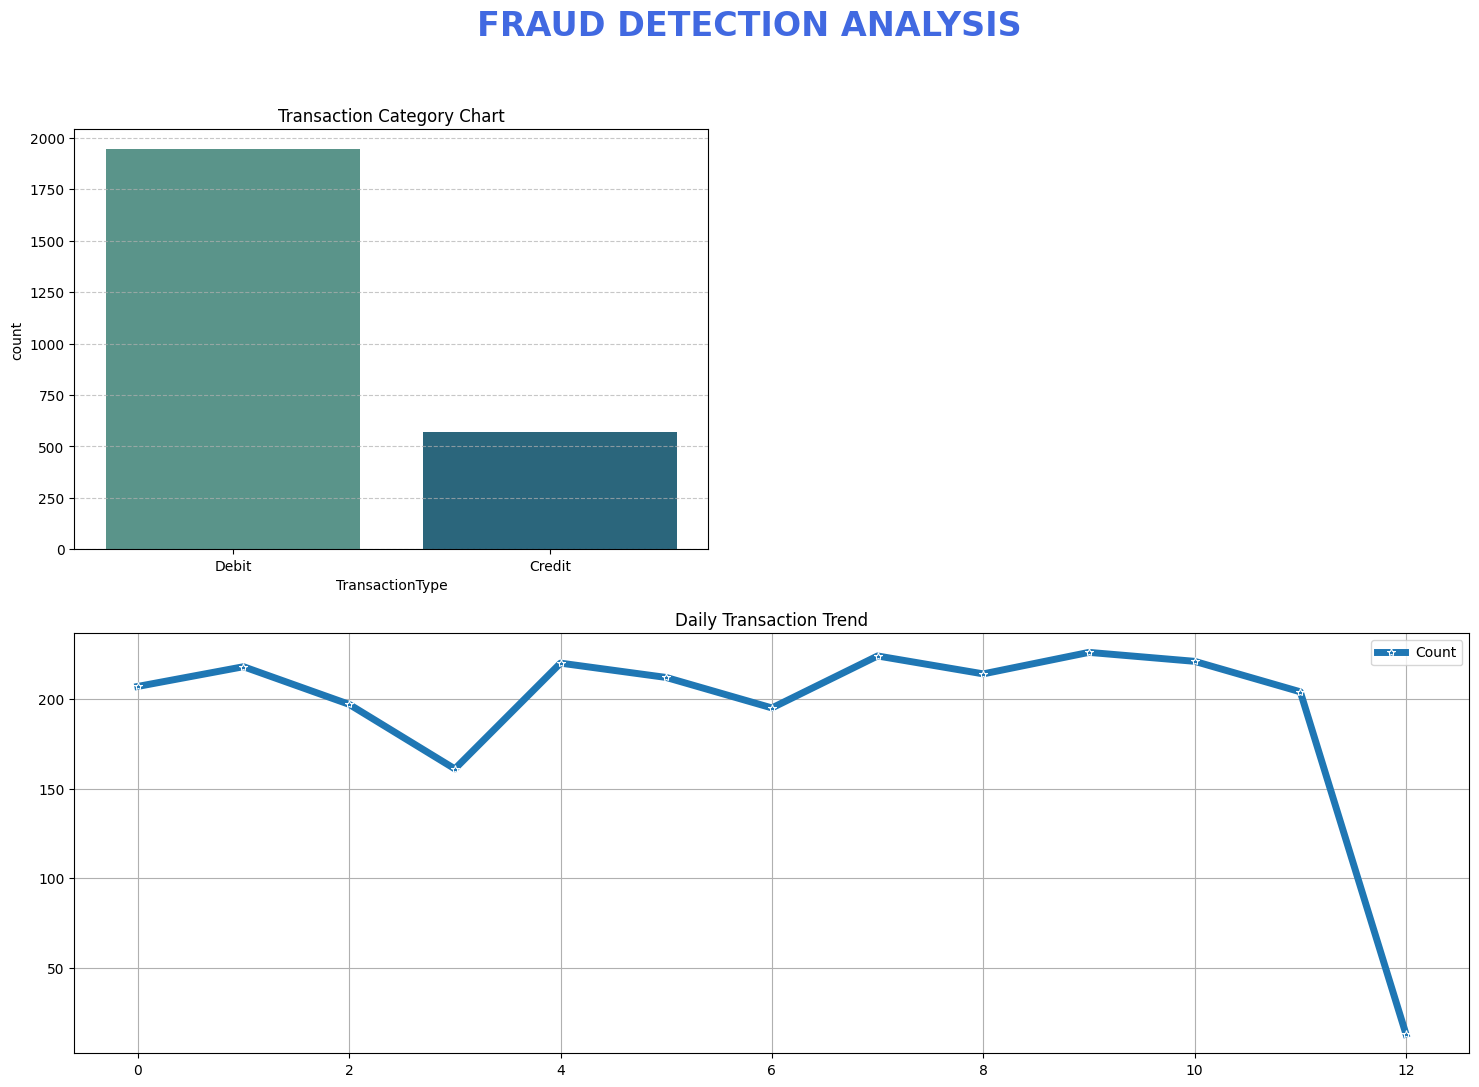

In [109]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization

fig , axes = plt.subplot_mosaic([['l_top', 'r_top'],
                                  ['bottom', 'bottom']],
                                  figsize = (18,12))
plt.suptitle("FRAUD DETECTION ANALYSIS", fontweight = "bold", fontsize = 24, y = 0.98, color = "royalblue")

#BAR GRAPH - TRANSACTION CATEGORY CHART
# category = df.groupby("TransactionType").value_counts().reset_index()
sns.countplot(data = df, x = "TransactionType" , ax = axes['l_top'], palette = "crest", hue = "TransactionType")
axes['l_top'].set_title("Transaction Category Chart")
axes['l_top'].grid(axis = 'y', alpha = 0.7, linestyle = "--")

#Line Chart - Daily Transaction Trend
df["TransactionDate"] = pd.to_datetime(df["TransactionDate"])
daily = df.groupby(df['TransactionDate'].dt.to_period('M'))['TransactionID'].count().reset_index(name='Count')
sns.lineplot(daily, marker = '*',  ax= axes['bottom'], linewidth = 5)
axes['bottom'].set_title("Daily Transaction Trend")
axes['bottom'].grid(True)

fig.delaxes(axes['r_top'])

In [122]:
#top 10 transactions

top_10 = df['TransactionAmount'].nlargest(10).reset_index()
print(top_10)

# as we have already created dictionary of suspecious transactions named query_2.
df2 = pd.DataFrame(query_2)

df2.to_csv("SuspeciousTransactions.csv", index = False)

   index  TransactionAmount
0    653            1919.11
1   1438            1831.02
2    340            1830.00
3   1634            1762.28
4   2414            1664.33
5   1247            1647.74
6   1788            1612.37
7    755            1607.55
8    898            1531.31
9   1984            1512.99
